In [1]:
import os
import sys

# Move up one directory if your notebook is in a subfolder (like 'notebooks')
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from src.digit_predict import load_model

In [3]:
# Get the project directory (root)
ROOT_DIR = Path.cwd().parent

# IMAGE_FILE_NAME = "sudoku.png"
IMAGE_FILE_NAME = "sudoku-4.png"
# IMAGE_FILE_NAME = "sudoku-5.png"

IMAGE_PATH = ROOT_DIR / "data" / IMAGE_FILE_NAME

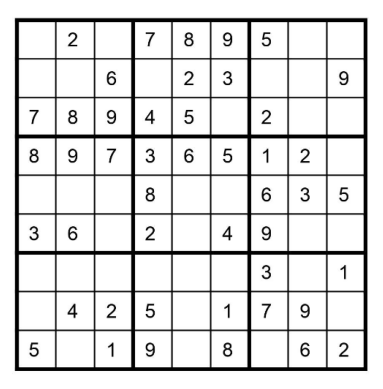

In [4]:

# Import the image and turn into grey scale
img = cv2.imread(IMAGE_PATH)
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(grey, cmap='gray')
plt.axis('off')
plt.show()

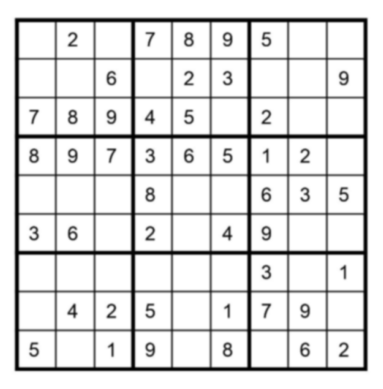

In [5]:
# Apply Gaussian blur effect to remove high frequency noises
blurred = cv2.GaussianBlur(grey, (5, 5), 0)

plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()

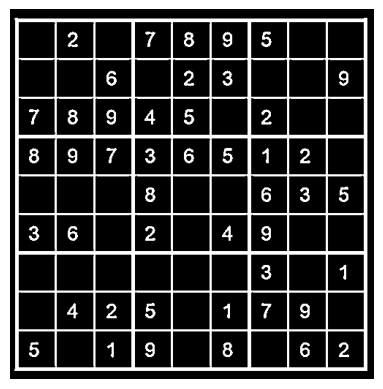

In [6]:
# Convert the blurry greyscale image into sharp black-and-white only image
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blockSize=11, C=2)

plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

In [7]:
# Find all the contours of the Sudoku board
# NOTE: the contours are unsorted
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort all of the contours in decending order
contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Extract the outer contour (which is the largest)
board_contour = contours[0]

# Calculate the perimeter
peri = cv2.arcLength(board_contour, True)

print(f"Perimeter: {peri}")

approx = cv2.approxPolyDP(board_contour, 0.01 * peri, True)

# Make sure that there are 4 vertices
if len(approx) != 4:
    raise ValueError("Could not find a 4-sided Sudoku board.")

Perimeter: 1929.0710676908493


In [8]:
def sort_corners(pts):
    # Helper to sort points: [top-left, top-right, bottom-right, bottom-left]
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

In [9]:
pts1 = np.float32([pts[0] for pts in approx])
sorted_pts = sort_corners(pts1)

print(f"Sorted corners:\n {sorted_pts}")

Sorted corners:
 [[  7.  12.]
 [488.  12.]
 [488. 494.]
 [  6. 494.]]


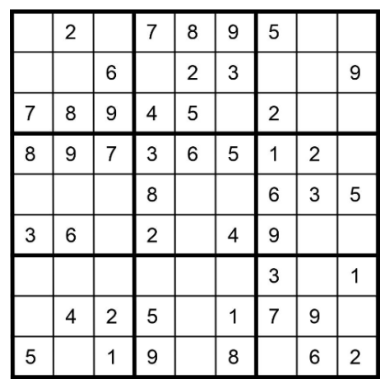

In [10]:
OUTPUT_SIZE = 450

dst_pts = np.array([
    [0, 0],                           # Top-Left destination
    [OUTPUT_SIZE - 1, 0],             # Top-Right destination
    [OUTPUT_SIZE - 1, OUTPUT_SIZE - 1], # Bottom-Right destination
    [0, OUTPUT_SIZE - 1]              # Bottom-Left destination
], dtype="float32")

# Calculate the perspective transform matrix
M = cv2.getPerspectiveTransform(sorted_pts, dst_pts)

# Wrap the original image to get the final flat square
flat_board = cv2.warpPerspective(grey, M, (OUTPUT_SIZE, OUTPUT_SIZE))

plt.imshow(flat_board, cmap='gray')
plt.axis('off')
plt.show()

In [11]:
# Answer
ans = [
  [0, 0, 0, 5, 7, 0, 0, 0, 0],
  [0, 1, 7, 0, 0, 0, 4, 0, 5],
  [0, 0, 2, 0, 0, 1, 0, 0, 0],
  [0, 7, 0, 0, 0, 6, 0, 0, 9],
  [8, 0, 0, 0, 1, 0, 0, 0, 4],
  [4, 0, 0, 3, 0, 0, 0, 7, 0],
  [0, 0, 0, 6, 0, 0, 7, 0, 0],
  [9, 0, 6, 0, 0, 0, 5, 3, 0],
  [0, 0, 0, 0, 8, 9, 0, 0, 0],
]

ans_4 = [
  [0, 2, 0, 7, 8, 9, 5, 0, 0],
  [0, 0, 6, 0, 2, 3, 0, 0, 9],
  [7, 8, 9, 4, 5, 0, 2, 0, 0],
  [8, 9, 7, 3, 6, 5, 1, 2, 0],
  [0, 0, 0, 8, 0, 0, 6, 3, 5],
  [3, 6, 0, 2, 0, 4, 9, 0, 0],
  [0, 0, 0, 0, 0, 0, 3, 0, 1],
  [0, 4, 2, 5, 0, 1, 7, 9, 0],
  [5, 0, 1, 9, 0, 8, 0, 6, 2],
]

ans_5 = [
  [6, 5, 9, 0, 1, 0, 2, 8, 0],
  [1, 0, 0, 0, 5, 0, 0, 3, 0],
  [2, 0, 0, 8, 0, 0, 0, 1, 0],
  [0, 0, 0, 1, 3, 5, 0, 7, 0],
  [8, 0, 0, 9, 0, 0, 0, 0, 2],
  [0, 0, 3, 0, 7, 8, 6, 4, 0],
  [3, 0, 2, 0, 0, 9, 0, 0, 4],
  [0, 0, 0, 0, 0, 1, 8, 0, 0],
  [0, 0, 8, 7, 6, 0, 0, 0, 0],
]

if IMAGE_FILE_NAME == "sudoku.png":
  ans = ans
elif IMAGE_FILE_NAME == "sudoku-4.png":
  ans = ans_4
elif IMAGE_FILE_NAME == "sudoku-5.png":
  ans = ans_5
else:
  ans = ans

# Flatten the matrix
flattened_ans = [item for sublist in ans for item in sublist]

In [12]:
grid = []
cell_size = flat_board.shape[0] // 9
incorrect_cells = []

MODEL_PATH = ROOT_DIR / "models" / "digit_recognition_model_TMNIST.keras"

model = load_model(MODEL_PATH)

idx = 0
for r in range(9):
    row = []
    for c in range(9):

        # Crop the cell
        x1, y1 = c * cell_size, r * cell_size
        x2, y2 = x1 + cell_size, y1 + cell_size
        cell = flat_board[y1:y2, x1:x2]

        # Remove the outer margin to avoid boarders
        margin = int(cell_size * 0.2)
        cell = cell[
            margin:cell_size-margin,
            margin:cell_size-margin
        ]

        blur = cv2.GaussianBlur(cell, (3, 3), 0)

        thresh = cv2.adaptiveThreshold(
            blur,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11,  # Block size (must be an odd number, adjust based on cell size)
            2    # Constant subtracted from the mean
        )

        # Remove noises by using a 2x2 kernel
        kernel = np.ones((2, 2), np.uint8)
        thresh = cv2.morphologyEx(
            thresh,
            cv2.MORPH_OPEN,
            kernel
        )

        # Find the contour of the digit
        contours, _ = cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        predicted_digit = 0
        confidence = -1.0

        # If there is no contour, then we deduce the current cell is blank
        if len(contours) == 0:
            row.append(0)
        else:
            # Find the largest area
            largest = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest)

            # If the largest area is less than a threshold, then it must be a noise or an artifact
            cell_area = cell.shape[0] * cell.shape[1]
            min_area_threshold = cell_area * 0.01

            if area < min_area_threshold:
                row.append(0)
            else:
                # Crop the digit
                x, y, w, h = cv2.boundingRect(largest)

                # If the bounding box is small that means there is no digit to crop
                if w == 0 or h == 0:
                    row.append(0)
                    continue

                # Crop the digit
                digit = thresh[y:y+h, x:x+w]
                h_digit, w_digit = digit.shape

                # Resize the digit but also preserve the aspect
                target_size = 18
                scale = target_size / max(h_digit, w_digit)
                new_w = max(1, int(w_digit * scale))
                new_h = max(1, int(h_digit * scale))
                resized_digit = cv2.resize(digit, (new_w, new_h))

                # Put the digit in the center of a 28x28 canvas
                canvas = np.zeros((28, 28), dtype=np.uint8)
                x_offset = (28 - new_w) // 2
                y_offset = (28 - new_h) // 2
                canvas[
                    y_offset:y_offset+new_h,
                    x_offset:x_offset+new_w
                ] = resized_digit

                # Normalize the input to the model
                cell_input = (
                    canvas
                    .reshape(1, 28, 28, 1)
                    .astype("float32") / 255.0
                )

                # Predict the digit
                predictions = model.predict(cell_input, verbose=0)

                predicted_digit = np.argmax(predictions, axis=-1)[0]
                confidence = np.max(predictions)

                row.append(int(predicted_digit))

        # DEBUG: Capture the incorrect digit
        if predicted_digit != flattened_ans[idx]:

            incorrect_cells.append({
                'img': canvas.copy(),
                'pos': (r, c),
                'pred': int(predicted_digit),
                'true': flattened_ans[idx],
                'conf': float(confidence)
            })

        idx += 1

    grid.append(row)

if incorrect_cells:
    num_plots = len(incorrect_cells)
    fig, axes = plt.subplots(1, num_plots, figsize=(num_plots * 3, 3))

    plt.suptitle("Incorrect Predicitons", fontsize=16, fontweight='bold', y=0.98)

    # Handle the case where there is only 1 low confidence cell
    if num_plots == 1:
        axes = [axes]

    for ax, data in zip(axes, incorrect_cells):
        ax.imshow(data['img'], cmap='gray')
        ax.set_title(f"({data['pos'][0]},{data['pos'][1]})\nPred: {data['pred']} ({data['conf']:.2%})\nTruth: {data['true']}")
        ax.axis('off')

    # Plot the incorrect predictions and save them as an image
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave the top 5% to be blank for the super title
    plt.savefig('../result.png', dpi=300, bbox_inches='tight')
    plt.show()

print(f"Accuracy: {(1 - len(incorrect_cells) / 81) * 100:.2f}%")

# Check the number of cells is correct
for row in grid:
    if len(row) != 9:
        raise ValueError("The number of cells in #{} is incorrect")

if len(grid) != 9:
    raise ValueError("The number of rows is incorrect")

# Print the board
print("Board: [")
for row in grid:
    print(f"  {row},")
print("]")

2026-06-06 08:46:02.471397: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-06 08:46:02.471418: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-06 08:46:02.471423: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1780753562.471433   27249 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780753562.471446   27249 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-06-06 08:46:02.707380: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Accuracy: 100.00%
Board: [
  [0, 2, 0, 7, 8, 9, 5, 0, 0],
  [0, 0, 6, 0, 2, 3, 0, 0, 9],
  [7, 8, 9, 4, 5, 0, 2, 0, 0],
  [8, 9, 7, 3, 6, 5, 1, 2, 0],
  [0, 0, 0, 8, 0, 0, 6, 3, 5],
  [3, 6, 0, 2, 0, 4, 9, 0, 0],
  [0, 0, 0, 0, 0, 0, 3, 0, 1],
  [0, 4, 2, 5, 0, 1, 7, 9, 0],
  [5, 0, 1, 9, 0, 8, 0, 6, 2],
]
